# PBMC 10k: top-2000 vs top-2000 plus append

Labeled 10x PBMC 10k (v3). Both arms fix `n_top_genes=2000` and share
one Leiden resolution. The standard arm is exact top-2000
(`balance_method="none"`). The scFair arm keeps that ranking and
appends 200 genes. The score is majority-vote purity against gold
`cell_type`: each Leiden cluster takes its most common label, and a
cell is an error if it disagrees. Over-clustering is not penalized.

Package default elsewhere is `n_top_genes="auto"`. This notebook locks
`n` so the comparison is only the cutoff tail.


## Data

```text
examples/data/pbmc_10k_v3_labeled.h5ad
```

Not on PyPI. Public counts: [10x Genomics](https://www.10xgenomics.com/datasets).


In [1]:
%matplotlib inline
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scfair as scf
from sklearn.metrics import adjusted_rand_score

sc.settings.verbosity = 1
sc.set_figure_params(dpi=100, facecolor="white", frameon=False)

DATA = Path("../../examples/data/pbmc_10k_v3_labeled.h5ad")
if not DATA.exists():
    DATA = Path("examples/data/pbmc_10k_v3_labeled.h5ad")

adata0 = ad.read_h5ad(DATA)
if "counts" in adata0.layers:
    adata0.X = adata0.layers["counts"].copy()

print(adata0)
print(adata0.obs["cell_type"].value_counts().to_string())
print("scfair", scf.__version__)


AnnData object with n_obs × n_vars = 10638 × 20136
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'cell_type', 'marker_label'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'chemistry', 'dataset_id', 'label_source'
    layers: 'counts'
cell_type
CD4_T          3283
Mono_CD14      3251
B              1522
CD8_T          1133
NK              592
Mono_FCGR3A     376
DC              312
Platelet        169
scfair 0.10.0


## Shared recipe

Only `balance_method` changes. After HVG the matrix is not subset;
`sc.tl.pca` uses the HVG mask.


In [2]:
RESOLUTION = 0.5
RANDOM_STATE = 0


def run_pipeline(balance_method: str):
    a = adata0.copy()
    scf.pp.highly_variable_genes(
        a,
        n_top_genes=2000,
        balance_method=balance_method,
        diagnose=False,
        progress=False,
        random_state=RANDOM_STATE,
    )
    n_hvg = int(a.var["highly_variable"].sum())
    sc.pp.normalize_total(a, target_sum=1e4)
    sc.pp.log1p(a)
    if hasattr(a.X, "toarray"):
        a.X = a.X.toarray()
    sc.pp.scale(a, max_value=10)
    sc.tl.pca(a, n_comps=30, svd_solver="arpack")
    sc.pp.neighbors(a, n_neighbors=15, n_pcs=30, random_state=RANDOM_STATE)
    sc.tl.leiden(
        a,
        resolution=RESOLUTION,
        flavor="igraph",
        n_iterations=2,
        directed=False,
        random_state=RANDOM_STATE,
    )
    sc.tl.umap(a, random_state=RANDOM_STATE)
    a.uns["n_hvg"] = n_hvg
    return a


emb_std = run_pipeline("none")
emb_fair = run_pipeline("append")
print(f"standard: {emb_std.uns['n_hvg']} HVGs, {emb_std.obs['leiden'].nunique()} clusters")
print(f"append:   {emb_fair.uns['n_hvg']} HVGs, {emb_fair.obs['leiden'].nunique()} clusters")


standard: 2000 HVGs, 18 clusters
append:   2200 HVGs, 19 clusters


## Errors


In [3]:
def majority_errors(pred: pd.Series, true: pd.Series) -> dict:
    pred = pred.astype(str)
    true = true.astype(str)
    mapping = {
        cl: true[pred == cl].value_counts().idxmax() for cl in pred.unique()
    }
    mapped = pred.map(mapping)
    ok = mapped.to_numpy() == true.to_numpy()
    per = []
    for t in sorted(true.unique()):
        m = true.to_numpy() == t
        e = int((~ok[m]).sum())
        per.append(
            {"cell_type": t, "n_cells": int(m.sum()), "n_misclustered": e}
        )
    return {
        "n_misclustered": int((~ok).sum()),
        "ari": float(adjusted_rand_score(true, pred)),
        "n_clusters": int(pred.nunique()),
        "correct": ok,
        "per_type": pd.DataFrame(per),
    }


gold = adata0.obs["cell_type"].astype(str)
stats_std = majority_errors(emb_std.obs["leiden"], gold.loc[emb_std.obs_names])
stats_fair = majority_errors(emb_fair.obs["leiden"], gold.loc[emb_fair.obs_names])

summary = pd.DataFrame(
    [
        {
            "method": "top-2000",
            "n_HVG": emb_std.uns["n_hvg"],
            "n_clusters": stats_std["n_clusters"],
            "n_misclustered": stats_std["n_misclustered"],
            "ARI": stats_std["ari"],
        },
        {
            "method": "top-2000 + append",
            "n_HVG": emb_fair.uns["n_hvg"],
            "n_clusters": stats_fair["n_clusters"],
            "n_misclustered": stats_fair["n_misclustered"],
            "ARI": stats_fair["ari"],
        },
    ]
)
print(summary.to_string(index=False))


           method  n_HVG  n_clusters  n_misclustered      ARI
         top-2000   2000          18             119 0.559755
top-2000 + append   2200          19              60 0.583739


In [4]:
per = (
    stats_std["per_type"]
    .rename(columns={"n_misclustered": "err_top2000"})
    .merge(
        stats_fair["per_type"].rename(columns={"n_misclustered": "err_append"}),
        on=["cell_type", "n_cells"],
    )
)
per["delta"] = per["err_top2000"] - per["err_append"]
per.sort_values("n_cells")


,cell_type,n_cells,err_top2000,err_append,delta
7,Platelet,169,9,0,9
3,DC,312,1,11,-10
5,Mono_FCGR3A,376,11,12,-1
6,NK,592,0,2,-2
2,CD8_T,1133,7,9,-2
0,B,1522,0,0,0
4,Mono_CD14,3251,69,7,62
1,CD4_T,3283,22,19,3


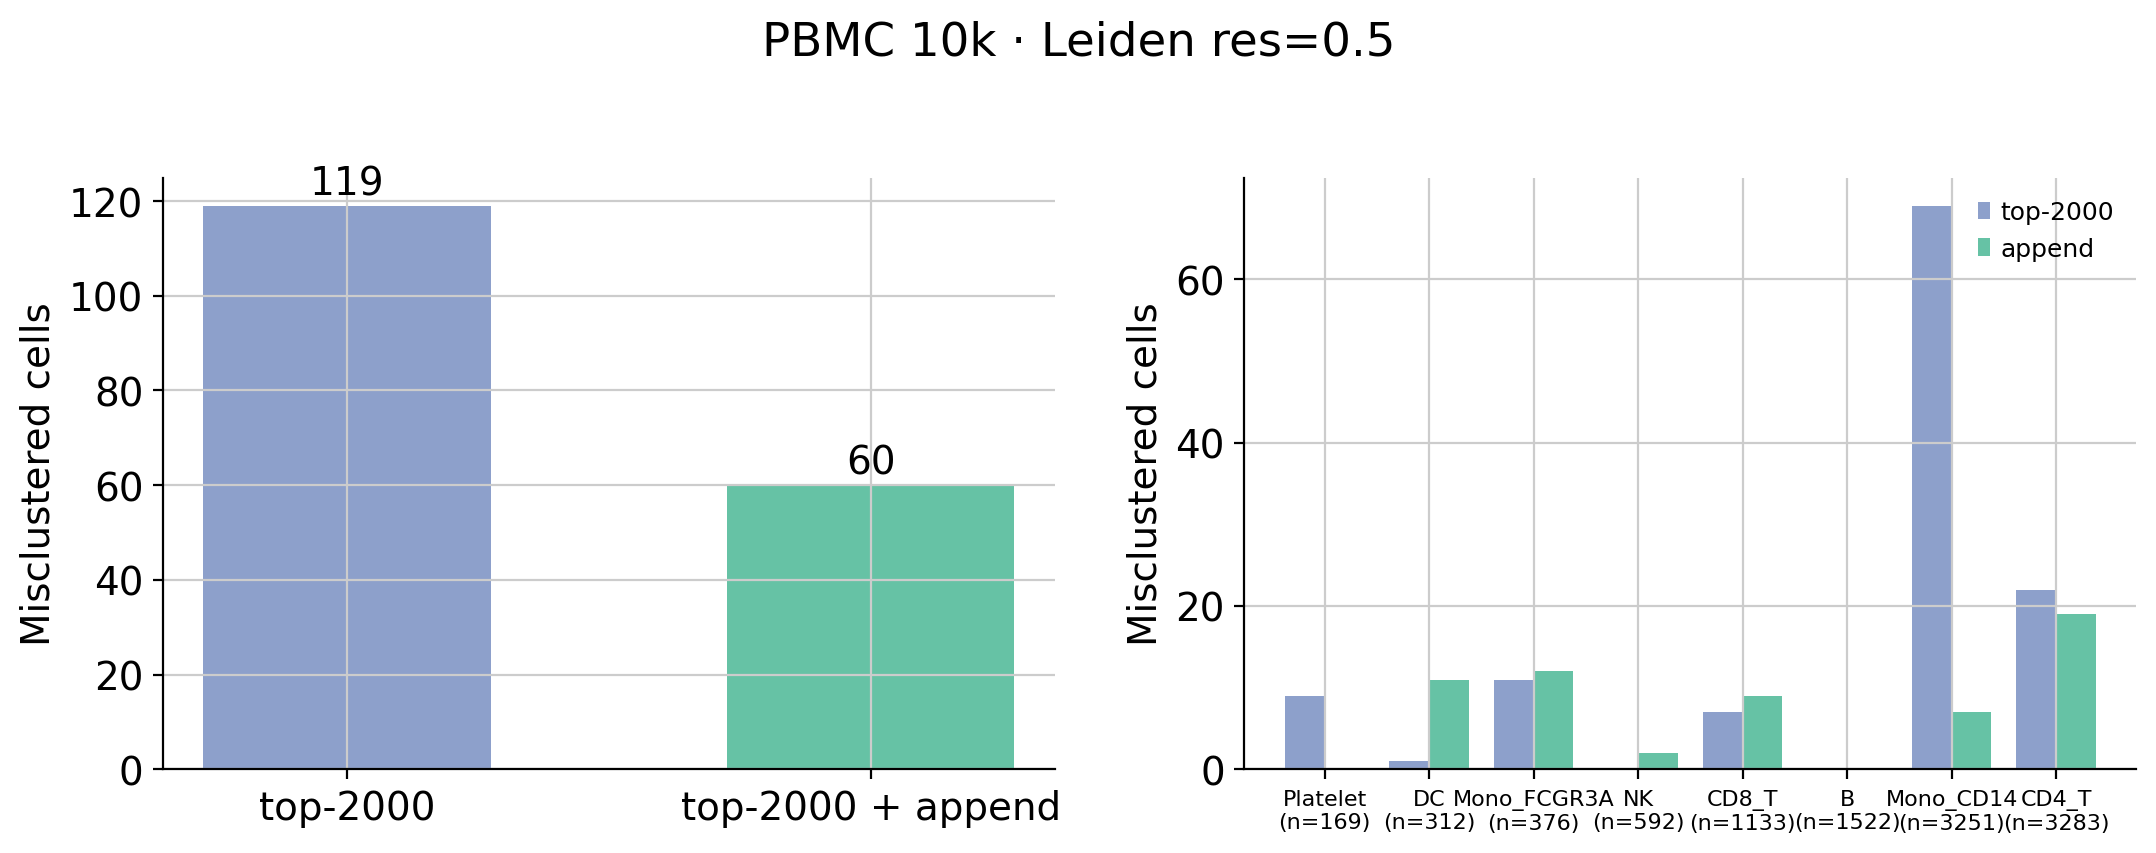

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.2))

ax = axes[0]
methods = ["top-2000", "top-2000 + append"]
errs = [stats_std["n_misclustered"], stats_fair["n_misclustered"]]
bars = ax.bar(methods, errs, color=["#8da0cb", "#66c2a5"], width=0.55)
for b, e in zip(bars, errs):
    ax.text(b.get_x() + b.get_width() / 2, e + max(errs) * 0.02, str(e), ha="center")
ax.set_ylabel("Misclustered cells")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax = axes[1]
x = np.arange(len(per))
w = 0.38
order = per.sort_values("n_cells")
ax.bar(x - w / 2, order["err_top2000"], w, label="top-2000", color="#8da0cb")
ax.bar(x + w / 2, order["err_append"], w, label="append", color="#66c2a5")
ax.set_xticks(x)
ax.set_xticklabels(
    [f"{r.cell_type}\n(n={r.n_cells})" for r in order.itertuples()],
    fontsize=8,
)
ax.set_ylabel("Misclustered cells")
ax.legend(frameon=False, fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.suptitle(f"PBMC 10k · Leiden res={RESOLUTION}", y=1.02)
fig.tight_layout()
plt.show()


## UMAP


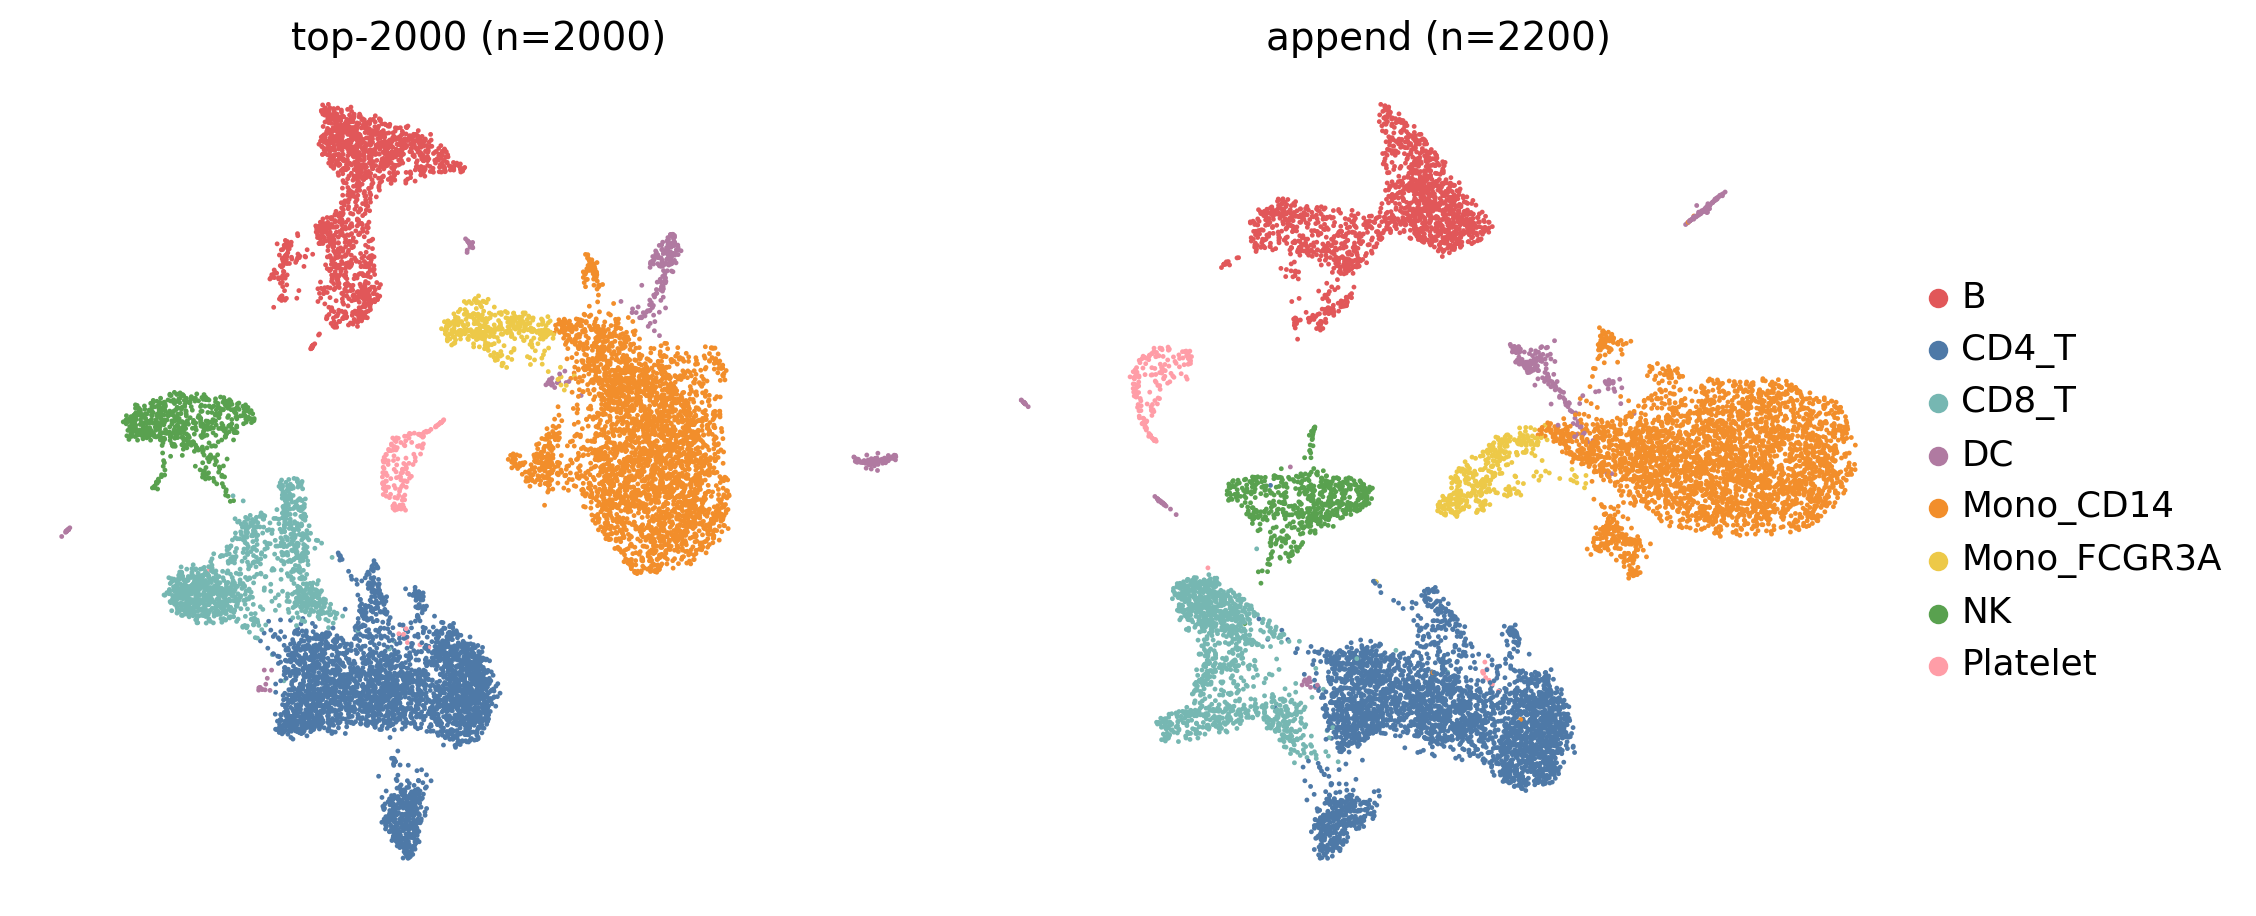

In [6]:
palette = {
    "CD4_T": "#4e79a7",
    "Mono_CD14": "#f28e2b",
    "B": "#e15759",
    "CD8_T": "#76b7b2",
    "NK": "#59a14f",
    "Mono_FCGR3A": "#edc948",
    "DC": "#b07aa1",
    "Platelet": "#ff9da7",
}
type_order = gold.value_counts().index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))
for ax, emb, title in [
    (axes[0], emb_std, f"top-2000 (n={emb_std.uns['n_hvg']})"),
    (axes[1], emb_fair, f"append (n={emb_fair.uns['n_hvg']})"),
]:
    sc.pl.umap(
        emb,
        color="cell_type",
        groups=type_order,
        palette=palette,
        ax=ax,
        show=False,
        title=title,
        frameon=False,
        legend_loc="right margin" if ax is axes[1] else "none",
        size=12,
    )
fig.tight_layout()
plt.show()


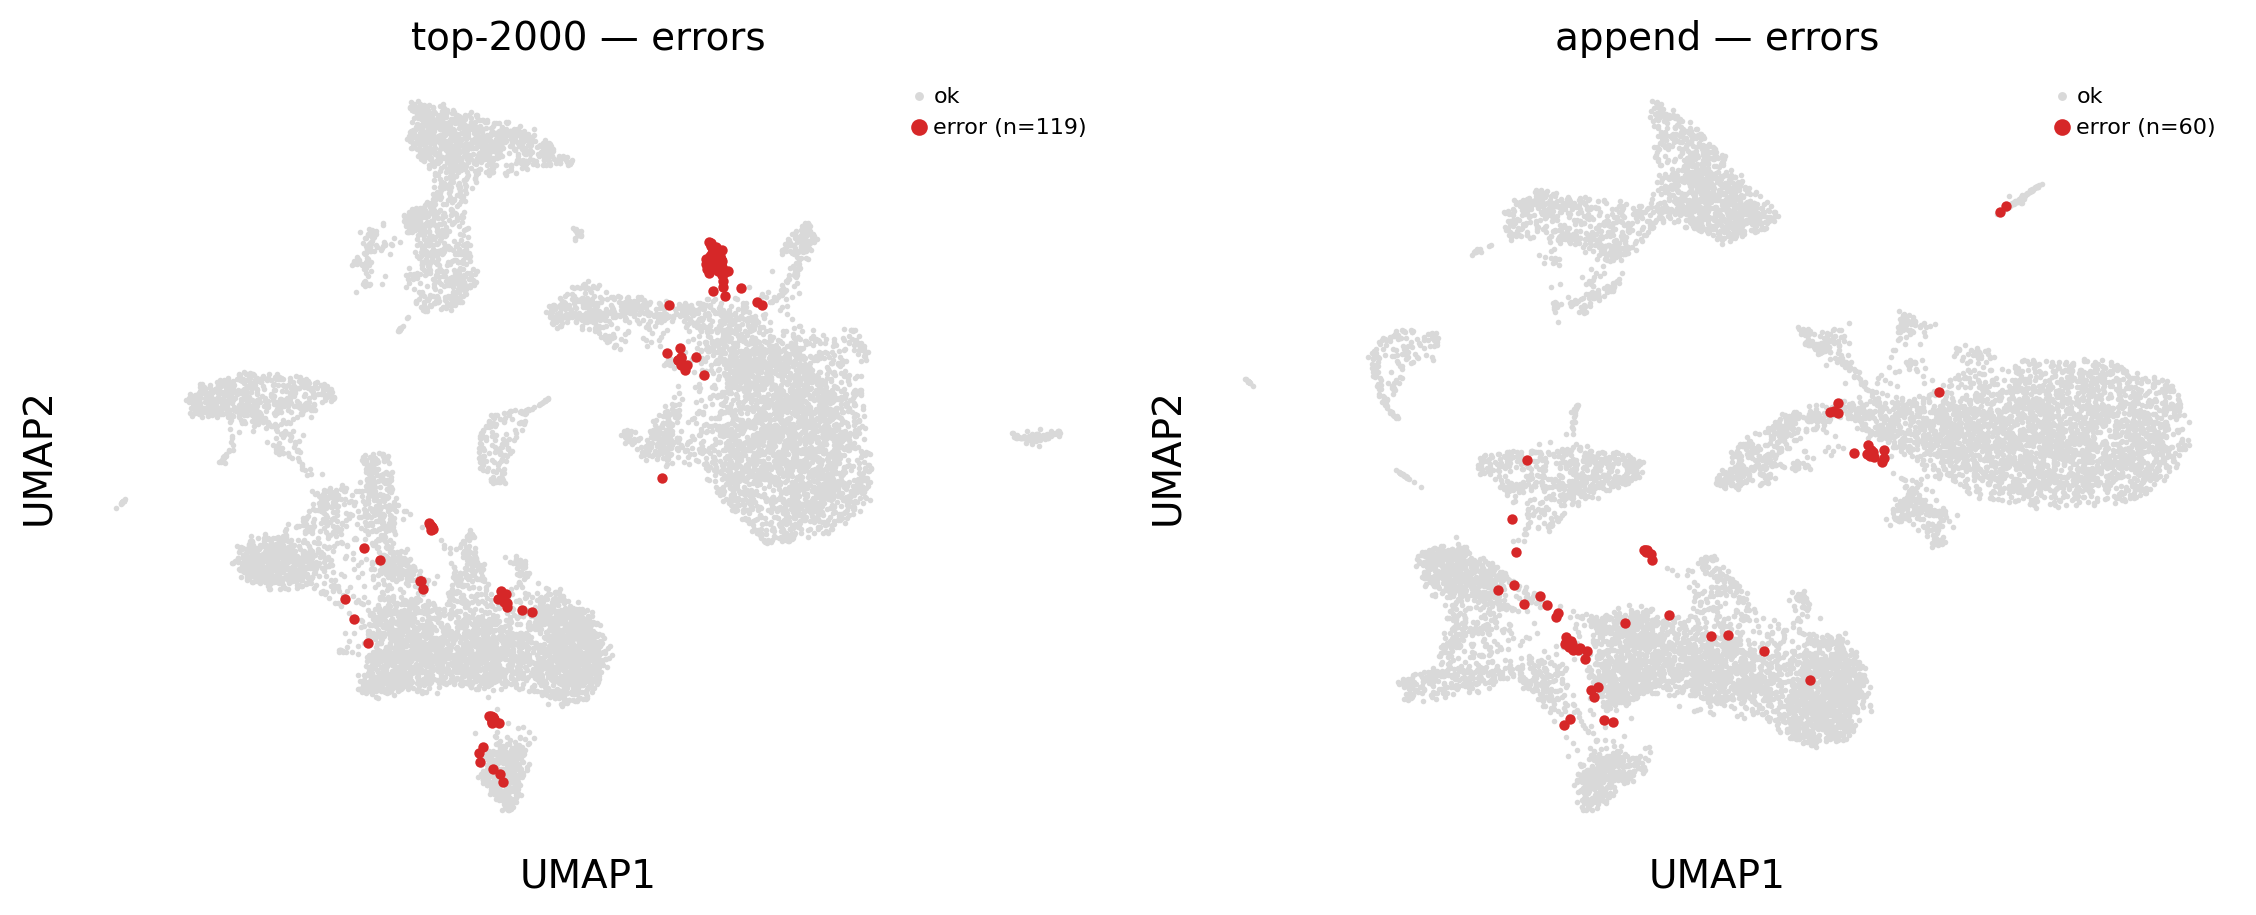

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))
for ax, emb, st, title in [
    (axes[0], emb_std, stats_std, "top-2000, errors"),
    (axes[1], emb_fair, stats_fair, "append, errors"),
]:
    xy = emb.obsm["X_umap"]
    ok = st["correct"]
    ax.scatter(xy[ok, 0], xy[ok, 1], s=4, c="0.85", linewidths=0, rasterized=True, label="ok")
    ax.scatter(
        xy[~ok, 0],
        xy[~ok, 1],
        s=14,
        c="#d62728",
        linewidths=0,
        rasterized=True,
        label=f"error (n={st['n_misclustered']})",
    )
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.legend(frameon=False, fontsize=8, loc="best", markerscale=1.6)
fig.tight_layout()
plt.show()


Read the per-type table before treating the total as a uniform win.
Some types improve, some get worse. Keep the recipe locked when you
compare methods.

Unlabeled analysis uses the package default (`n_top_genes="auto"` +
append): {doc}`pbmc3k_first_analysis`.
